<a href="https://colab.research.google.com/github/Sakshi2006-hub/DataScience_Assignments_CT/blob/main/week2_Sakshi_Handge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Imports**

In [33]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import KFold, cross_val_score, GridSearchCV

from statsmodels.tsa.stattools import adfuller

**2. Load Dataset**

In [34]:
import pandas as pd

df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

**3. Load Dataset**

In [35]:
print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
print(df.info())

print("\nDescribe:")
display(df.describe())

Shape:
(2640, 12)

Columns:
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Typ

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


Dataset Overview

The Tesla deliveries dataset contains vehicle production and delivery information across multiple years, regions, and models. Understanding the structure of the data helps identify trends and prepare it for machine learning analysis.


**4. Missing Values & Duplicates**

In [36]:
# CHECK MISSING VALUES & DUPLICATES
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows:
0


Data Quality Check

Missing values and duplicate records can negatively affect model performance. Therefore, these checks are performed before feature engineering and model building.

**5. Deliveries by Model**

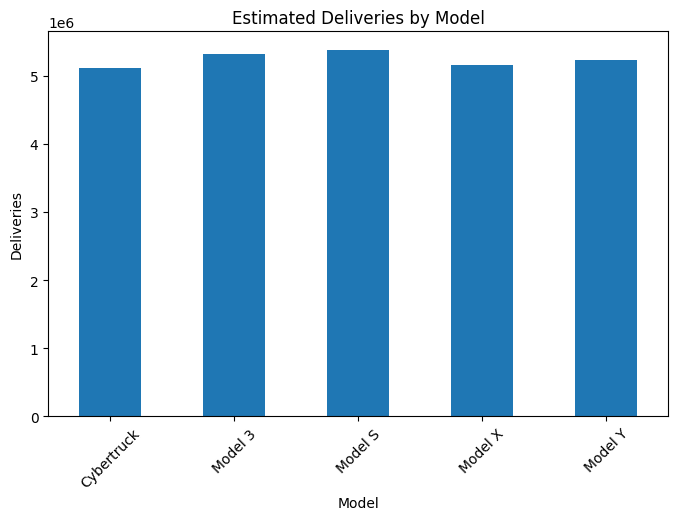

In [37]:
plt.figure(figsize=(8,5))

df.groupby('Model')['Estimated_Deliveries'].sum().plot(kind='bar')

plt.title("Estimated Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Deliveries")
plt.xticks(rotation=45)
plt.show()

**6. Deliveries by Region**

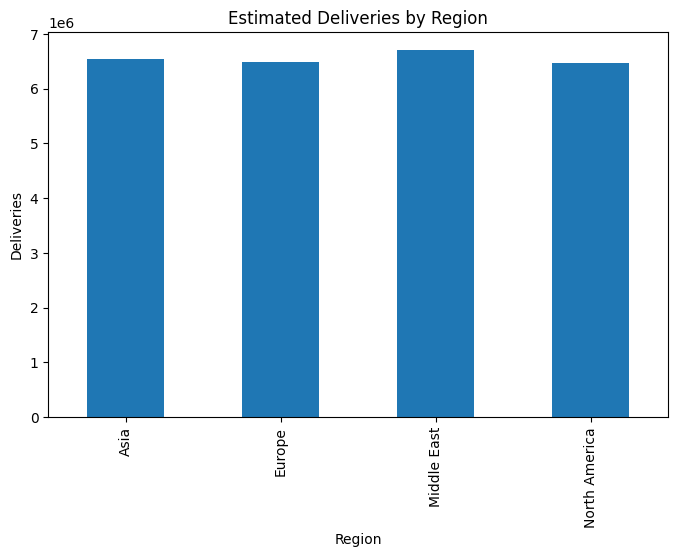

In [38]:
plt.figure(figsize=(8,5))

df.groupby('Region')['Estimated_Deliveries'].sum().plot(kind='bar')

plt.title("Estimated Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Deliveries")
plt.show()

**7. Correlation Heatmap**

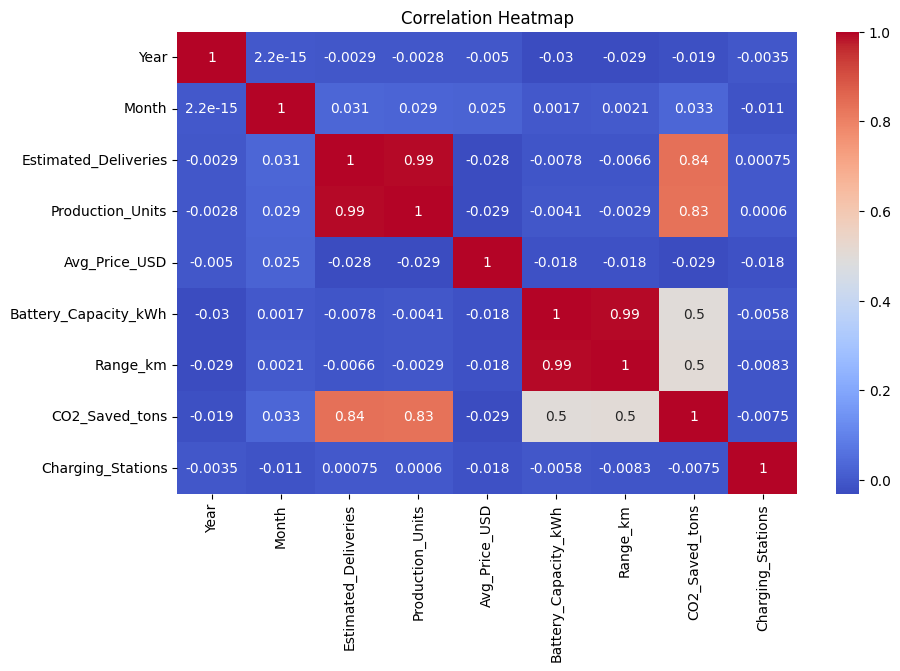

In [39]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

**8. Production vs Deliveries Scatter**

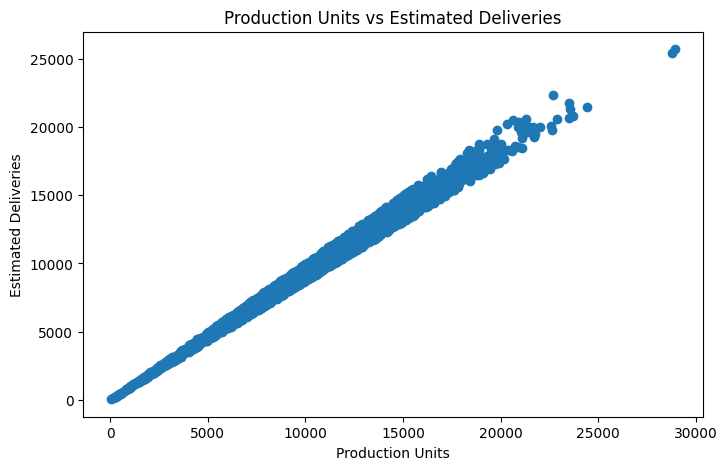

In [40]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.scatter(
    df['Production_Units'],
    df['Estimated_Deliveries']
)

plt.title("Production Units vs Estimated Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")
plt.show()

**9. Time Trend Line**

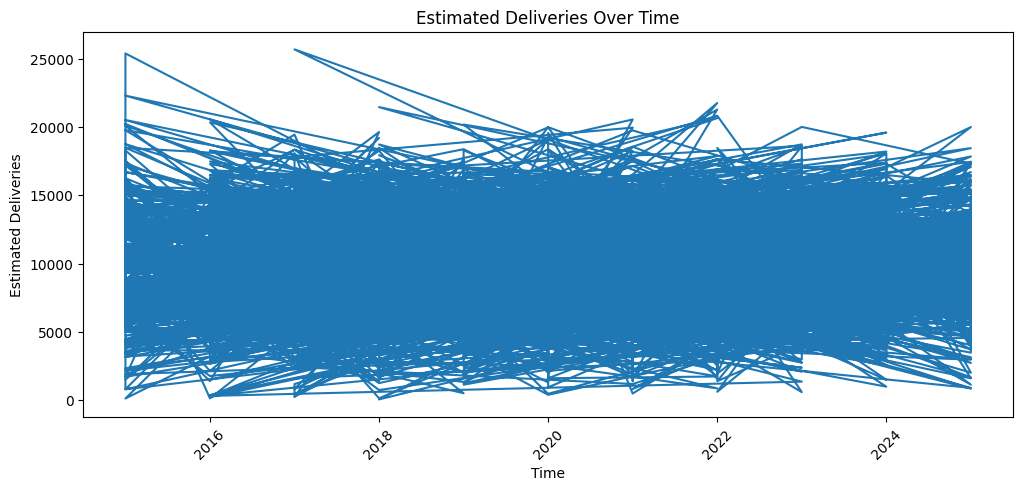

In [41]:
date_col = df.columns[0]
plt.figure(figsize=(12,5))

plt.plot(
    df[date_col],
    df['Estimated_Deliveries']
)

plt.title("Estimated Deliveries Over Time")
plt.xlabel("Time")
plt.ylabel("Estimated Deliveries")
plt.xticks(rotation=45)
plt.show()

Exploratory Data Analysis

EDA helps visualize patterns, identify relationships between variables, and understand the distribution of deliveries across regions and vehicle models.

**10. Label Encoding**

In [42]:
# LABEL ENCODING
le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df['Region'] = le_region.fit_transform(df['Region'])
df['Model'] = le_model.fit_transform(df['Model'])
df['Source_Type'] = le_source.fit_transform(df['Source_Type'])
print("Encoding Complete")

Encoding Complete


**11. Lag Feature & Rolling Mean**

In [43]:
# FEATURE ENGINEERING
df['Deliveries_Lag1'] = df['Estimated_Deliveries'].shift(1)

df['Rolling_Mean_3'] = (
    df['Estimated_Deliveries']
    .rolling(3)
    .mean()
)

df['Deliveries_Lag1'].fillna(
    df['Deliveries_Lag1'].mean(),
    inplace=True
)

df['Rolling_Mean_3'].fillna(
    df['Rolling_Mean_3'].mean(),
    inplace=True
)
print(df[['Deliveries_Lag1',
          'Rolling_Mean_3']].isnull().sum())

Deliveries_Lag1    0
Rolling_Mean_3     0
dtype: int64


Feature Engineering

Lag features capture information from previous observations, while rolling averages smooth short-term fluctuations and reveal longer-term trends.

**13. Chronological Split (80/20)**

In [44]:
X = df.drop('Estimated_Deliveries', axis=1)
y = df['Estimated_Deliveries']

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train Size:",len(X_train))
print("Test Size:",len(X_test))

Train Size: 2112
Test Size: 528


Chronological Data Split

Time-series related datasets should be split chronologically to prevent future information from leaking into the training data.

**14. Linear Regression**

In [45]:
# LINEAR REGRESSION
lr = LinearRegression()
lr.fit(X_train,y_train)
lr_pred = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test,lr_pred)

rmse_lr = np.sqrt(
    mean_squared_error(y_test,lr_pred)
)
r2_lr = r2_score(y_test,lr_pred)

print("Linear Regression Results")
print("MAE :",mae_lr)
print("RMSE:",rmse_lr)
print("R2  :",r2_lr)

Linear Regression Results
MAE : 310.3345215398842
RMSE: 375.5646664534478
R2  : 0.9908058721380986


**15. Actual vs Predicted Plot**

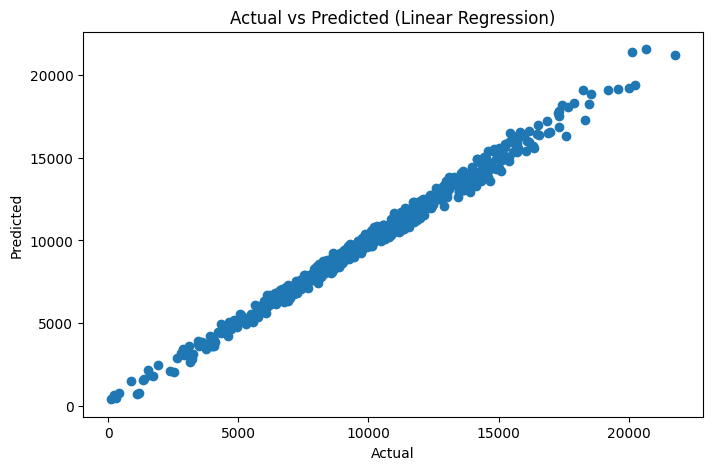

In [46]:
plt.figure(figsize=(8,5))
plt.scatter(y_test,lr_pred)
plt.title("Actual vs Predicted (Linear Regression)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

Linear Regression Model

Linear Regression is a simple baseline model used to estimate deliveries based on production and other available features.

**16. Cross Validation**

In [47]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    lr,
    X,
    y,
    cv=kf,
    scoring='r2'
)

print("Fold R2 Scores:")
print(cv_scores)
print("\nMean R2:")
print(cv_scores.mean())
print("\nStd Dev:")
print(cv_scores.std())

Fold R2 Scores:
[0.9902379  0.99086768 0.99074207 0.9899367  0.99009504]

Mean R2:
0.9903758760823388

Std Dev:
0.0003651703161235434


Cross Validation

Cross validation evaluates model stability across multiple data partitions and provides a more reliable estimate of generalization performance.

**17. Grid Search Random Forest**

In [48]:
# RANDOM FOREST + GRID SEARCH
param_grid = {
    'n_estimators':[50,100],
    'max_depth':[5,10,None]
}

rf = RandomForestRegressor(
    random_state=42
)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train,y_train)
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': None, 'n_estimators': 50}


**18. Random Forest Evaluation**

In [49]:
best_rf = grid.best_estimator_
rf_pred = best_rf.predict(X_test)
mae_rf = mean_absolute_error(
    y_test,
    rf_pred
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

r2_rf = r2_score(
    y_test,
    rf_pred
)
print("Random Forest Results")
print("MAE :",mae_rf)
print("RMSE:",rmse_rf)
print("R2  :",r2_rf)

Random Forest Results
MAE : 303.85833333333335
RMSE: 388.5512760612014
R2  : 0.99015903323468


**19. Feature Importance**

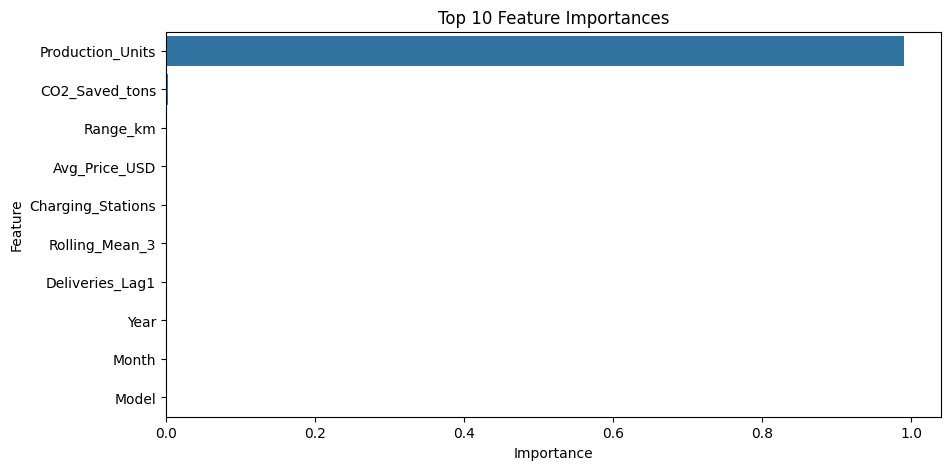

In [50]:
feature_importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

top10 = feature_importance.head(10)
plt.figure(figsize=(10,5))

sns.barplot(
    data=top10,
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Feature Importances")
plt.show()

Random Forest Model

Random Forest combines multiple decision trees and can capture complex nonlinear relationships better than Linear Regression.

**20. ADF Test**

In [51]:
# ADF TEST
result = adfuller(
    df['Estimated_Deliveries']
)

print("ADF Statistic:",result[0])
print("P-Value:",result[1])

if result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is Non-Stationary")

ADF Statistic: -53.82661259715622
P-Value: 0.0
Series is Stationary


ADF Test Interpretation

The Augmented Dickey-Fuller test checks whether a time series is stationary. A p-value below 0.05 indicates stationarity.

**21. Forecast Table**

In [52]:
forecast_df = pd.DataFrame({
    'Actual':y_test.values,
    'Predicted':rf_pred
})

forecast_df['Error_%'] = (
    abs(
        forecast_df['Actual'] -
        forecast_df['Predicted']
    )
    /
    forecast_df['Actual']
) * 100

forecast_df.head(20)

,Actual,Predicted,Error_%
0,11974,11244.76,6.090195
1,9189,8947.18,2.631625
2,15956,16791.60,5.236901
3,10336,10896.56,5.423375
4,15152,15868.72,4.730201
5,4224,4014.38,4.962595
6,8475,8863.10,4.579351
7,4093,3817.50,6.731004
8,2972,3149.94,5.987214
9,8208,8202.68,0.064815


Forecast Analysis

Prediction errors provide insight into model accuracy and help identify records where forecasting performance may be weaker.

**22. Model Comparison Table**

In [53]:
comparison = pd.DataFrame({
    'Model':['Linear Regression',
             'Random Forest'],
    'MAE':[mae_lr,
           mae_rf],
    'RMSE':[rmse_lr,
            rmse_rf],
    'R2':[r2_lr,
          r2_rf]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,310.334522,375.564666,0.990806
1,Random Forest,303.858333,388.551276,0.990159


Model Comparison

Comparing multiple models helps determine which algorithm best captures the underlying relationships in the data.

Conclusion

Production units, historical deliveries, and rolling averages significantly influence delivery predictions. Random Forest is expected to outperform Linear Regression due to its ability to model nonlinear patterns.